In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import math

In [35]:
# Set device
device = "cuda"

In [36]:
def linear_beta_schedule(timesteps, start=0.0001, end=0.02):
    return torch.linspace(start, end, timesteps)

def get_index_from_list(vals, t, x_shape):

    batch_size = t.shape[0]

    out = vals.gather(-1, t.cpu())

    out = out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))

    return out.to(t.device)

In [37]:
def forward_diffusion_sample(x_0, t, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod):

    noise = torch.randn_like(x_0)

    sqrt_alphas_cumprod_t = get_index_from_list(
        sqrt_alphas_cumprod, t, x_0.shape
    )

    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x_0.shape
    )

    mean = sqrt_alphas_cumprod_t * x_0
    variance = sqrt_one_minus_alphas_cumprod_t * noise

    return mean + variance, noise

In [38]:
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()

        self.time_mlp = nn.Linear(time_emb_dim, out_ch)

        if up:
            # For upsampling blocks
            self.conv1 = nn.Conv2d(2 * in_ch, out_ch, kernel_size=3, padding=1)

            # Replace ConvTranspose2d with Upsample + Conv
            self.transform = nn.Sequential(
                nn.Upsample(scale_factor=2, mode="nearest"),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
            )

        else:
            # For downsampling blocks
            self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

            self.transform = nn.Conv2d(
                out_ch, out_ch, kernel_size=4, stride=2, padding=1
            )

        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)

        self.bn1 = nn.BatchNorm2d(out_ch)
        self.bn2 = nn.BatchNorm2d(out_ch)

        self.relu = nn.ReLU()

    def forward(self, x, t):

        h = self.conv1(x)
        h = self.bn1(h)
        h = self.relu(h)

        time_emb = self.time_mlp(t)
        time_emb = self.relu(time_emb)

        time_emb = time_emb[..., None, None]

        h = h + time_emb

        h = self.conv2(h)
        h = self.bn2(h)
        h = self.relu(h)

        return self.transform(h)

In [39]:
class SinusoidalPositionEmbeddings(nn.Module):

    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):

        device = time.device

        half_dim = self.dim // 2

        freq_scale = math.log(10000) / (half_dim - 1)

        inv_freq = torch.exp(
            torch.arange(half_dim, device=device) * -freq_scale
        )

        sinusoid_input = time[:, None] * inv_freq[None, :]

        emb = torch.cat(
            [sinusoid_input.sin(), sinusoid_input.cos()],
            dim=-1
        )

        return emb

In [40]:
class SimpleUnet(nn.Module):

    def __init__(self):

        super().__init__()

        image_channels = 1
        down_channels = (64, 128, 256)
        up_channels = (256, 128, 64)

        time_emb_dim = 32

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )

        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)

        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i+1], time_emb_dim)
            for i in range(len(down_channels)-1)
        ])

        self.ups = nn.ModuleList([
            Block(up_channels[i], up_channels[i+1], time_emb_dim, up=True)
            for i in range(len(up_channels)-1)
        ])

        self.output = nn.Conv2d(up_channels[-1], image_channels, 1)

    def forward(self, x, timestep):

        t = self.time_mlp(timestep)

        x = self.conv0(x)

        residual_inputs = []

        for down in self.downs:

            x = down(x, t)

            residual_inputs.append(x)

        for up in self.ups:

            residual_x = residual_inputs.pop()

            x = torch.cat((x, residual_x), dim=1)

            x = up(x, t)

        return self.output(x)

In [41]:
IMG_SIZE = 32
BATCH_SIZE = 128
EPOCHS = 25
LR = 0.001
TIMESTEPS = 600

In [42]:
betas = linear_beta_schedule(timesteps=TIMESTEPS)

alphas = 1. - betas

alphas_cumprod = torch.cumprod(alphas, axis=0)

alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1,0), value=1.0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)

sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

In [43]:
transforms_mnist = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transforms_mnist
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

In [44]:
model = SimpleUnet().to(device)

optimizer = optim.Adam(model.parameters(), lr=LR)

criterion = nn.MSELoss()

loss_history = []

In [45]:
print("Training started...")

for epoch in range(EPOCHS):

    epoch_loss = 0.0

    for step, (images, _) in enumerate(
        tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    ):

        optimizer.zero_grad()

        x0 = images.to(device)

        t = torch.randint(
            0,
            TIMESTEPS,
            (BATCH_SIZE,),
            device=device
        ).long()

        xt, noise_target = forward_diffusion_sample(
            x0, t, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod
        )

        predicted_noise = model(xt, t)

        loss = criterion(noise_target, predicted_noise)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)

    loss_history.append(avg_epoch_loss)

    print("Epoch Loss:", avg_epoch_loss)

print("Training finished.")

Training started...


Epoch 1/25: 100%|██████████| 468/468 [01:14<00:00,  6.26it/s]


Epoch Loss: 0.1821041460761912


Epoch 2/25: 100%|██████████| 468/468 [01:14<00:00,  6.29it/s]


Epoch Loss: 0.07377686080896956


...

Epoch Loss: 0.02839580200548865


Epoch 24/25: 100%|██████████| 468/468 [01:14<00:00,  6.32it/s]


Epoch Loss: 0.028493201081505697


Epoch 25/25: 100%|██████████| 468/468 [01:14<00:00,  6.30it/s]

Epoch Loss: 0.028299385852888864
Training finished.


In [46]:
@torch.no_grad()
def sample_timestep(x, t):

    betas_t = get_index_from_list(betas, t, x.shape)

    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x.shape
    )

    sqrt_recip_alphas_t = get_index_from_list(
        sqrt_recip_alphas, t, x.shape
    )

    predicted_noise = model(x, t)

    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * predicted_noise / sqrt_one_minus_alphas_cumprod_t
    )

    posterior_variance_t = get_index_from_list(
        posterior_variance, t, x.shape
    )

    if t.all().item() == 0:

        return model_mean

    else:

        noise = torch.randn_like(x)

        return model_mean + torch.sqrt(posterior_variance_t) * noise

In [47]:
@torch.no_grad()
def generate_images(num_images=16):

    img = torch.randn(
        (num_images, 1, IMG_SIZE, IMG_SIZE),
        device=device
    )

    for i in tqdm(reversed(range(0, TIMESTEPS)),
                  desc="Sampling",
                  total=TIMESTEPS):

        t = torch.full((num_images,), i, device=device, dtype=torch.long)

        img = sample_timestep(img, t)

    img = (img + 1) * 0.5

    img = img.clamp(0,1)

    return img

Sampling: 100%|██████████| 600/600 [00:03<00:00, 175.79it/s]


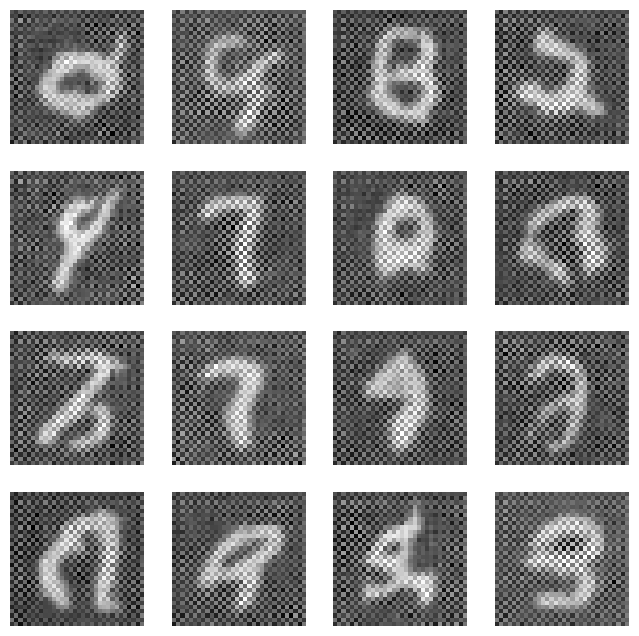

In [48]:
generated_images = generate_images(16)

plt.figure(figsize=(8,8))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        generated_images[i].cpu().squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.show()